## Simple RNN 

In [161]:
import numpy as np
import pandas as pd
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

In [162]:
df = pd.read_csv(r"Reviews.csv")
# df.head()

texts = df["Text"].head(10).astype(str).tolist()
print(df["Text"].head(10))
print(texts)

labels = np.array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
3    If you are looking for the secret ingredient i...
4    Great taffy at a great price.  There was a wid...
5    I got a wild hair for taffy and ordered this f...
6    This saltwater taffy had great flavors and was...
7    This taffy is so good.  It is very soft and ch...
8    Right now I'm mostly just sprouting this so my...
9    This is a very healthy dog food. Good for thei...
Name: Text, dtype: str
['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.', 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to r

### Preprocessing

In [163]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

print("word Index: ")
print(tokenizer.word_index)

print("\n Sequences: ")
print(sequences)
# lengths = [len(seq) for seq in sequences]
# print(lengths)

word Index: 
{'the': 1, 'and': 2, 'this': 3, 'a': 4, 'it': 5, 'is': 6, 'i': 7, 'was': 8, 'very': 9, 'taffy': 10, 'of': 11, 'my': 12, 'good': 13, 'if': 14, 'with': 15, 'to': 16, 'product': 17, 'in': 18, 'recommend': 19, 'for': 20, 'have': 21, 'dog': 22, 'not': 23, 'too': 24, 'chewy': 25, 'treat': 26, 'you': 27, 'are': 28, 'great': 29, 'at': 30, 'flavors': 31, 'would': 32, 'food': 33, 'found': 34, 'all': 35, 'than': 36, 'better': 37, 'as': 38, 'jumbo': 39, 'peanuts': 40, 'were': 41, 'small': 42, 'that': 43, 'around': 44, 'into': 45, 'tiny': 46, 'highly': 47, 'yummy': 48, 'witch': 49, 'got': 50, 'root': 51, 'beer': 52, 'ordered': 53, 'which': 54, 'there': 55, 'only': 56, 'just': 57, 'soft': 58, 'candy': 59, 'so': 60, 'bought': 61, 'several': 62, 'vitality': 63, 'canned': 64, 'products': 65, 'them': 66, 'be': 67, 'quality': 68, 'looks': 69, 'more': 70, 'like': 71, 'stew': 72, 'processed': 73, 'meat': 74, 'smells': 75, 'labrador': 76, 'finicky': 77, 'she': 78, 'appreciates': 79, 'most': 80,

In [164]:
max_length = 100

X = pad_sequences(
    sequences,
    maxlen = max_length,
    padding = "post"
)

print(X)

[[  7  21  61  62  11   1  63  64  22  33  65   2  21  34  66  35  16  67
   11  13  68   1  17  69  70  71   4  72  36   4  73  74   2   5  75  37
   12  76   6  77   2  78  79   3  17  37  36  80   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [ 17  81  82  38  39  83  40   1  40  41  84  42  85  86  23  87  14   3
    8  88  89  90  14   1  91  92  16  93   1  17  38  39   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  3   6   4  94  43  95  96  44   4  97  98   5   6   4  99 100 101 102
   15 103  18   3 104 105   2   5   6 106  45  46 107   2 108 109 110  15
  111 112   2   5   6   4 

## Model Creation

In [165]:
model = Sequential()

model.add(Embedding(
    input_dim = len(tokenizer.word_index) + 1,
    output_dim = 8,
    input_length = max_length
))

c:\Users\yuvra\Desktop\UNI\NLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [166]:

model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(16))
model.add(Dense(1, activation = "sigmoid"))

## Model Complie

In [ ]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [168]:
history = model.fit(
    X,
    labels,
    epochs = 20,
    verbose = 1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7000 - loss: 0.6225
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9000 - loss: 0.4676
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9000 - loss: 0.3862
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9000 - loss: 0.3279
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.2751
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.2288
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.2013
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.1805
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.1559
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.1337
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.1194
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.1082
Epo

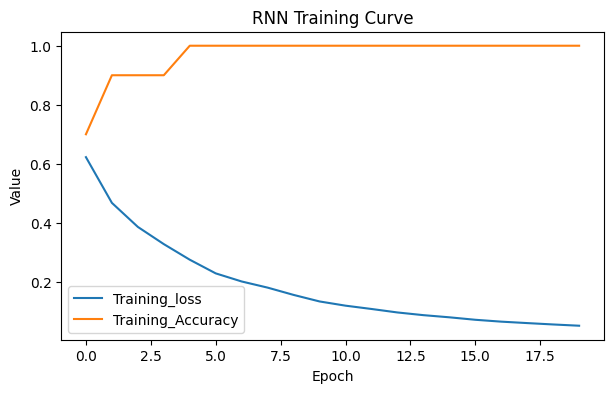

In [169]:
import matplotlib.pyplot as plt
plt.figure(figsize = (7,4))
plt.plot(history.history['loss'], label='Training_loss')
plt.plot(history.history['accuracy'], label='Training_Accuracy')
plt.title("RNN Training Curve")
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.show()